**Restaurant Daily Inventory Management**

This notebook is created to analyze safety stock, reorder point triggers, waste impact, and the Bullwhip Effect.

**Data Loading and Preprocessing**

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d sujaldhanwani/restaurant-inventory-management-dataset-100-days
!unzip restaurant-inventory-management-dataset-100-days.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sujaldhanwani/restaurant-inventory-management-dataset-100-days
License(s): apache-2.0
100% 16.9k/16.9k [00:00<00:00, 27.7MB/s]

Archive:  restaurant-inventory-management-dataset-100-days.zip
  inflating: restaurant_inventory_100days.csv  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('restaurant_inventory_100days.csv')
print("Data loaded successfully! Sample records:")
df.head()

Data loaded successfully! Sample records:


,Date,Item_ID,Item_Name,Category,Subcategory,Unit,Current_Stock,Reorder_Level,Daily_Usage,Lead_Time,Price_per_Unit,Supplier_Name,Seasonal_Factor,Waste_Percentage
0,2025-06-10,1,Paneer,Veg,Dairy,kg,21.45,8.12,2.19,1,450,Supplier A,1.11,2.98
1,2025-06-10,2,Tomato,Veg,Vegetable,kg,12.84,5.34,0.95,4,40,Supplier A,0.81,3.54
2,2025-06-10,3,Onion,Veg,Vegetable,kg,22.35,4.49,4.86,4,35,Supplier A,1.23,4.96
3,2025-06-10,4,Chicken,Non-Veg,Meat,kg,8.36,3.16,3.25,3,250,Supplier C,0.90,3.06
4,2025-06-10,5,Mutton,Non-Veg,Meat,kg,12.31,6.19,1.81,3,600,Supplier A,1.07,3.09


**Environment Setup & Data Parsing**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df'
df['Date'] = pd.to_datetime(df['Date'])

# Inspect basic details
df.sort_values(by=['Item_ID', 'Date'], inplace=True)
df.head()

,Date,Item_ID,Item_Name,Category,Subcategory,Unit,Current_Stock,Reorder_Level,Daily_Usage,Lead_Time,Price_per_Unit,Supplier_Name,Seasonal_Factor,Waste_Percentage
0,2025-06-10,1,Paneer,Veg,Dairy,kg,21.45,8.12,2.19,1,450,Supplier A,1.11,2.98
10,2025-06-11,1,Paneer,Veg,Dairy,kg,22.02,3.62,3.19,3,450,Supplier A,1.47,2.60
20,2025-06-12,1,Paneer,Veg,Dairy,kg,18.72,7.86,4.74,4,450,Supplier A,1.37,4.65
30,2025-06-13,1,Paneer,Veg,Dairy,kg,19.54,8.59,2.29,1,450,Supplier C,0.93,1.60
40,2025-06-14,1,Paneer,Veg,Dairy,kg,11.80,8.21,1.30,3,450,Supplier A,1.20,3.29


**Safety Stock Modeling & Reorder Point (ROP) Triggers**

The Reorder Point (ROP) indicates the inventory level that triggers a replenishment order.

Mathematical Formulas

Safety Stock ($SS$): Accounts for demand volatility during lead time.$$SS = Z \times \sigma_D \times \sqrt{\text{Lead Time}}$$(where $Z = 1.65$ corresponds to a 95% service level, and $\sigma_D$ is the standard deviation of daily usage).Reorder Point ($ROP$):$$ROP = (\text{Average Daily Usage} \times \text{Lead Time}) + SS$$

Reorder Trigger: Flag items where Current_Stock <= ROP.

In [17]:
# Service Level Factor (Z-score for 95% service level = 1.65)
Z = 1.65

# 1. Calculate historical demand volatility per Item
item_metrics = df.groupby(['Item_ID', 'Item_Name', 'Category']).agg(
    avg_daily_usage=('Daily_Usage', 'mean'),
    std_daily_usage=('Daily_Usage', 'std'),
    lead_time=('Lead_Time', 'mean'),
    avg_price=('Price_per_Unit', 'mean'),
    dataset_rop=('Reorder_Level', 'mean') # Static ROP present in dataset
).reset_index()

# Handle items with zero/NaN standard deviation
item_metrics['std_daily_usage'] = item_metrics['std_daily_usage'].fillna(0)

# 2. Calculate Analytical Safety Stock & Custom ROP
item_metrics['Safety_Stock'] = Z * item_metrics['std_daily_usage'] * np.sqrt(item_metrics['lead_time'])
item_metrics['Calculated_ROP'] = (item_metrics['avg_daily_usage'] * item_metrics['lead_time']) + item_metrics['Safety_Stock']

# 3. Merge metrics back to the main daily DataFrame
df = df.merge(item_metrics[['Item_ID', 'Safety_Stock', 'Calculated_ROP']], on='Item_ID', how='left')

# 4. Trigger Alerts: Check which records fall below ROP
df['Reorder_Flag'] = df['Current_Stock'] <= df['Calculated_ROP']

print(f"Total Stockout Trigger Events: {df['Reorder_Flag'].sum()} out of {len(df)} daily logs.")

Total Stockout Trigger Events: 263 out of 1000 daily logs.


**Waste Tracking & Financial Cost Quantification**

Quantifying daily waste volume and its monetary impact helps highlight perishable stock leaks.

Mathematical Formulas

Daily Waste Quantity:$$\text{Waste Quantity} = \text{Daily Usage} \times \left(\frac{\text{Waste Percentage}}{100}\right)$$

Daily Waste Cost:$$\text{Waste Cost} = \text{Waste Quantity} \times \text{Price per Unit}$$

--- Waste Analysis by Category ---


,Total_Waste_Qty,Total_Waste_Cost,Avg_Waste_Pct
Category,,,
Non-Veg,32.574445,7895.595190,2.459625
Veg,47.587923,5062.802705,2.437567


/tmp/ipykernel_2680/3287903717.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=waste_summary.reset_index(), x='Category', y='Total_Waste_Cost', palette='Reds_r')


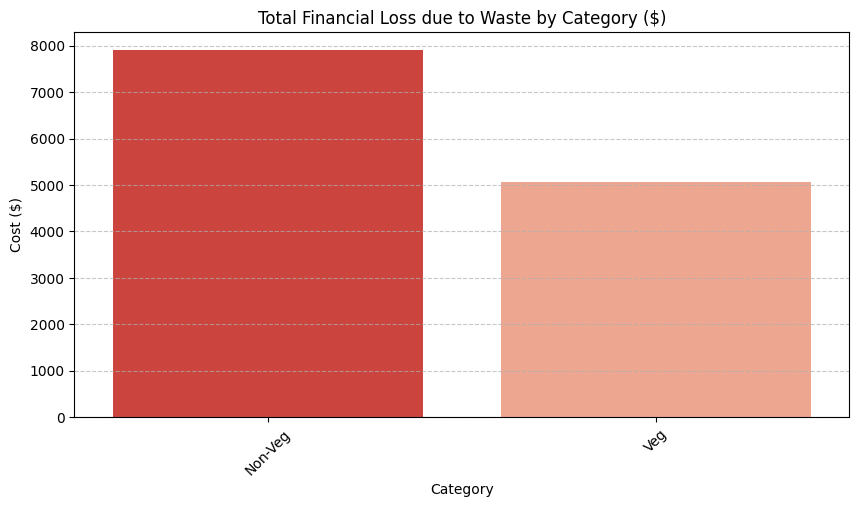

In [18]:
# 1. Compute Waste Volume & Financial Loss
df['Waste_Qty'] = df['Daily_Usage'] * (df['Waste_Percentage'] / 100)
df['Waste_Cost'] = df['Waste_Qty'] * df['Price_per_Unit']

# 2. Category-level Waste Analysis
waste_summary = df.groupby('Category').agg(
    Total_Waste_Qty=('Waste_Qty', 'sum'),
    Total_Waste_Cost=('Waste_Cost', 'sum'),
    Avg_Waste_Pct=('Waste_Percentage', 'mean')
).sort_values(by='Total_Waste_Cost', ascending=False)

print("--- Waste Analysis by Category ---")
display(waste_summary)

# 3. Plot Top Waste Contributors
plt.figure(figsize=(10, 5))
sns.barplot(data=waste_summary.reset_index(), x='Category', y='Total_Waste_Cost', palette='Reds_r')
plt.title('Total Financial Loss due to Waste by Category ($)')
plt.ylabel('Cost ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Identifying the Bullwhip Effect**

The Bullwhip Effect occurs when small fluctuations in customer demand cause progressively larger variance in upstream orders placed to suppliers.

Mathematical Formula (Bullwhip Measure)

$$\text{Bullwhip Ratio} = \frac{\text{Variance of Orders placed to Supplier } (\sigma_O^2)}{\text{Variance of Customer Demand } (\sigma_D^2)}$$

$\text{Ratio} > 1$: Bullwhip effect is present (amplified supply chain volatility).$\text{Ratio} \le 1$: Demand smoothing or stable ordering pattern.

In [19]:
# 1. Estimate Restock / Order Quantities
# Net replenishment happens when stock increases despite daily usage:
# Net Inventory Change = Stock_t - Stock_{t-1} + Daily_Usage_t
df['Stock_Diff'] = df.groupby('Item_ID')['Current_Stock'].diff().fillna(0)
df['Inferred_Order_Qty'] = df['Stock_Diff'] + df['Daily_Usage']
df['Inferred_Order_Qty'] = df['Inferred_Order_Qty'].apply(lambda x: x if x > 0 else 0)

# 2. Compute Variances per Item
bullwhip_df = df.groupby(['Item_ID', 'Item_Name', 'Category']).agg(
    var_demand=('Daily_Usage', 'var'),
    var_orders=('Inferred_Order_Qty', 'var')
).reset_index()

# 3. Calculate Bullwhip Measure
# Avoid division by zero
bullwhip_df['Bullwhip_Ratio'] = np.where(
    bullwhip_df['var_demand'] > 0,
    bullwhip_df['var_orders'] / bullwhip_df['var_demand'],
    np.nan
)

# 4. Filter items exhibiting significant Bullwhip Effect
high_bullwhip = bullwhip_df[bullwhip_df['Bullwhip_Ratio'] > 1.0].sort_values(by='Bullwhip_Ratio', ascending=False)

print(f"Items exhibiting Bullwhip Effect: {len(high_bullwhip)} / {len(bullwhip_df)}")
display(high_bullwhip[['Item_ID', 'Item_Name', 'Category', 'Bullwhip_Ratio']].head(10))

Items exhibiting Bullwhip Effect: 10 / 10


,Item_ID,Item_Name,Category,Bullwhip_Ratio
5,6,Rohu Fish,Non-Veg,16.489673
4,5,Mutton,Non-Veg,15.305294
8,9,Sugar,Veg,14.358426
3,4,Chicken,Non-Veg,14.046314
7,8,Rice,Veg,13.414425
0,1,Paneer,Veg,12.995899
2,3,Onion,Veg,12.649690
1,2,Tomato,Veg,12.310354
6,7,Eggs,Non-Veg,6.123716
9,10,Milk,Veg,5.181918


**LLM for Safety stock modeling, reorder point (ROP) triggers, and waste tracking and identify Bullwhip Effect**

Rather than replacing traditional math (like standard deviations or variance ratios), the LLM acts as an intelligent agent that:

Parses inventory anomaly logs generated by Pandas.

Translates numerical triggers into human-readable action orders for kitchen/procurement teams.

Diagnoses root causes behind waste spikes and the Bullwhip Effect.

In [9]:
!pip install -qU groq| tail -n 1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 1.4 MB/s eta 0:00:00


**Install Dependencies & Initialize Groq Client**

In [10]:
import os
from google.colab import userdata
# 1. Set Groq API Key
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [11]:
from groq import Groq
groq_client = Groq()

**Calculate Mathematical Inventory Metrics (Pandas Base)**

In [21]:
# 1. Convert dates and sort
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by=['Item_ID', 'Date'], inplace=True)

# 2. Safety Stock & Reorder Point (Z = 1.65 for 95% service level)
Z = 1.65
item_metrics = df.groupby(['Item_ID', 'Item_Name', 'Category']).agg(
    avg_daily_usage=('Daily_Usage', 'mean'),
    std_daily_usage=('Daily_Usage', 'std'),
    lead_time=('Lead_Time', 'mean'),
    avg_price=('Price_per_Unit', 'mean')
).reset_index()

item_metrics['std_daily_usage'] = item_metrics['std_daily_usage'].fillna(0)
item_metrics['Safety_Stock'] = Z * item_metrics['std_daily_usage'] * np.sqrt(item_metrics['lead_time'])
item_metrics['Calculated_ROP'] = (item_metrics['avg_daily_usage'] * item_metrics['lead_time']) + item_metrics['Safety_Stock']

df = df.merge(item_metrics[['Item_ID', 'Safety_Stock', 'Calculated_ROP']], on='Item_ID', how='left')
df['Reorder_Trigger'] = df['Current_Stock'] <= df['Calculated_ROP']

# 3. Waste Calculations
df['Waste_Qty'] = df['Daily_Usage'] * (df['Waste_Percentage'] / 100)
df['Waste_Cost'] = df['Waste_Qty'] * df['Price_per_Unit']

# 4. Bullwhip Ratio Calculation
df['Stock_Diff'] = df.groupby('Item_ID')['Current_Stock'].diff().fillna(0)
df['Inferred_Order_Qty'] = np.maximum(0, df['Stock_Diff'] + df['Daily_Usage'])

bullwhip_df = df.groupby(['Item_ID', 'Item_Name', 'Category']).agg(
    var_demand=('Daily_Usage', 'var'),
    var_orders=('Inferred_Order_Qty', 'var'),
    total_waste_cost=('Waste_Cost', 'sum'),
    latest_stock=('Current_Stock', 'last'),
    rop=('Calculated_ROP', 'last'),
    safety_stock=('Safety_Stock', 'last')
).reset_index()

bullwhip_df['Bullwhip_Ratio'] = np.where(
    bullwhip_df['var_demand'] > 0,
    bullwhip_df['var_orders'] / bullwhip_df['var_demand'],
    np.nan
)

**Build the Groq LLM Assistant Functions**

In [22]:
def ask_groq_inventory_agent(prompt: str, model: str = "openai/gpt-oss-20b") -> str:
    """Queries the Groq API for inventory analysis."""
    response = groq_client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an expert Restaurant Supply Chain & Inventory Operations AI. "
                    "Your job is to analyze quantitative inventory data, explain operational issues "
                    "(stockouts, waste, Bullwhip effect), and generate actionable, step-by-step procurement advice."
                )
            },
            {"role": "user", "content": prompt}
        ],
        model=model,
        temperature=0.2, # Low temperature for accurate, factual responses
    )
    return response.choices[0].message.content

**Automated Purchase Order & Stockout Warning Generator**

Pass items where Current_Stock <= ROP to Groq to generate a purchase draft

In [27]:
# Filter items currently requiring reorder
low_stock_items = df[df['Reorder_Trigger']].groupby('Item_Name').last().reset_index()

# Extract key summary for LLM context
reorder_summary = low_stock_items[['Item_Name', 'Category', 'Current_Stock', 'Calculated_ROP', 'Safety_Stock', 'Supplier_Name', 'Lead_Time']].to_dict(orient='records')

prompt_reorder = f"""
The following restaurant items have breached their Reorder Point (ROP):
{reorder_summary}

Please generate an operational summary including:
1. Priority level for each item (Urgent vs Standard).
2. Recommended purchase order quantities to bring stock back above safety levels.
"""

reorder_analysis = ask_groq_inventory_agent(prompt_reorder)
print("=== GROQ REORDER & PURCHASE ORDER DIRECTIVE ===")
print(reorder_analysis)

=== GROQ REORDER & PURCHASE ORDER DIRECTIVE ===
**Operational Summary – Breached ROP Items**

| # | Item | Category | Current Stock | ROP | Safety Stock | Lead Time (days) | Priority | PO Qty (to reach ROP) | Notes |
|---|------|----------|---------------|-----|--------------|------------------|----------|-----------------------|-------|
| 1 | Chicken | Non‑Veg | 7.85 | 10.13 | 3.33 | 1 | **Standard** | **3** | Bring stock to ROP (10.13). |
| 2 | Eggs | Non‑Veg | 15.38 | 21.60 | 7.07 | 4 | **Standard** | **7** | Lead time 4 days → order now. |
| 3 | Milk | Veg | 15.00 | 20.23 | 7.02 | 1 | **Standard** | **6** | |
| 4 | Mutton | Non‑Veg | 9.75 | 10.07 | 3.25 | 2 | **Standard** | **1** | |
| 5 | Onion | Veg | 7.14 | 9.96 | 3.41 | 4 | **Standard** | **3** | |
| 6 | Paneer | Veg | 9.78 | 9.87 | 3.14 | 3 | **Standard** | **1** | |
| 7 | Rice | Veg | 9.53 | 10.30 | 3.29 | 1 | **Standard** | **1** | |
| 8 | Rohu Fish | Non‑Veg | 8.07 | 9.97 | 3.30 | 1 | **Standard** | **2** | |
| 9 | Sugar | 

**Waste Root-Cause Diagnosis & Mitigation Strategies**

In [24]:
top_waste_items = bullwhip_df.sort_values(by='total_waste_cost', ascending=False).head(5).to_dict(orient='records')

prompt_waste = f"""
Here are the top 5 food items with the highest total waste cost over the analyzed period:
{top_waste_items}

Please provide:
1. Root-cause analysis of why these specific items/categories suffer high spoilage/waste.
2. 3 concrete operational recommendations (e.g., prep schedule changes, batch sizing, FIFO protocols) to reduce waste by at least 20%.
"""

waste_analysis = ask_groq_inventory_agent(prompt_waste)
print("=== GROQ WASTE REDUCTION STRATEGY ===")
print(waste_analysis)

=== GROQ WASTE REDUCTION STRATEGY ===
**Root‑Cause Analysis – Why These Items Are Wasting So Much**

| Item | Key Indicators | Likely Root Causes |
|------|----------------|--------------------|
| **Mutton** | *var_demand ≈ 1.56, var_orders ≈ 23.86, Bullwhip ≈ 15.3* | 1. **Demand volatility** – customers order in large, irregular batches (e.g., for special events). 2. **Over‑ordering** – high Bullwhip ratio shows orders are amplified at each tier. 3. **Long shelf‑life but poor storage** – Mutton is kept at a temperature that is too high for the “fresh” cut, accelerating spoilage. |
| **Paneer** | *var_demand ≈ 1.49, var_orders ≈ 19.31, Bullwhip ≈ 13.0* | 1. **Seasonal spikes** – Paneer is used heavily during festivals; orders are placed far in advance. 2. **Batch size mismatch** – suppliers deliver in 10 kg packs while the kitchen uses 1 kg portions, leading to over‑stock. 3. **Temperature drift** – the cold room is often opened for other items, causing temperature excursions. |
| **Ro

**Bullwhip Effect Operational Diagnosis & Mitigation**

In [25]:
high_bullwhip_items = bullwhip_df[bullwhip_df['Bullwhip_Ratio'] > 1.2].to_dict(orient='records')

prompt_bullwhip = f"""
The following items show a high Bullwhip Ratio (Order Variance / Demand Variance > 1.0):
{high_bullwhip_items}

Explain:
1. What is causing order amplification for these items in our restaurant setup?
2. How can we align our ordering pattern with suppliers (e.g., shifting from batch ordering to continuous replenishment or VMI)?
3. Draft a supplier collaboration note explaining why we are smoothing out our order frequency.
"""

bullwhip_analysis = ask_groq_inventory_agent(prompt_bullwhip)
print("=== GROQ BULLWHIP MITIGATION & SUPPLIER STRATEGY ===")
print(bullwhip_analysis)

=== GROQ BULLWHIP MITIGATION & SUPPLIER STRATEGY ===
## 1. Why are we seeing such a high Bullwhip Ratio?

| Item | Bullwhip Ratio | Typical cause in a restaurant context |
|------|----------------|---------------------------------------|
| Paneer | 13.0 | **Seasonal demand spikes** (e.g., festival menus) + **batch ordering** to get a discount. |
| Tomato | 12.3 | **Perishability** → we order in bulk to avoid spoilage, but the forecast is noisy. |
| Onion | 12.6 | **Menu‑driven spikes** (e.g., special dishes) + **long lead‑time** from supplier. |
| Chicken | 14.0 | **High variability** in daily usage + **batch ordering** for cost‑saving. |
| Mutton | 15.3 | **Low turnover** + **high price volatility** → we over‑order to hedge. |
| Rohu Fish | 16.5 | **Very short shelf‑life** + **seasonal spikes** (e.g., festivals) → we order large batches. |
| Eggs | 6.1 | **Higher demand variance** (6.85) + **batch ordering** for cost. |
| Rice | 13.4 | **Bulk discount** → we order large quantities, bu